In [1]:
import geopandas as gpd
import sys
from pathlib import Path
path = Path().cwd().parent / "src" #to add the src directory to the path regognized by Python
sys.path.append(str(path))
import methods_two_point_correlation as mtpc
import save_load_pickle as slp
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.spatial import distance
import matplotlib.pyplot as plt
import sklearn.cluster as sk
import sys
from sklearn.metrics import silhouette_score
from shapely.geometry import Polygon,Point
from scipy.stats import entropy

# Parameters

In [2]:
#set paths
path = Path().cwd().parent
sys.path.append(str(path))
data_dir = path/"data/cities"
map_dir = path/"data/map"
plot_dir = path/"out/plot_fitted_parameters/"

In [7]:
name = "Switzerland" #name of country
nbins=20 # number of bins to make for every binning operation
out_dir = path /Path(f"out/2pcf/{name}")
file = out_dir / f"1_5_7000_3__300000.0_log_{nbins}" #name of dataset

diminish_radius = 1 # multiplication factor for the maximum radius, 
#to be lowered if the SP does not fit inside the considered border quick enough

N_run= 3 # number of random catalog generated for computing the 2PCF, needs to be the same as in the plotted data
size= 3000 #number of points each random catalog has
erase_nodes = False

In [8]:
#Load the polygon file for border
path_border = Path.cwd() / map_dir / f"{name}.geojson"
gdf_edge = gpd.read_file(path_border)

#load the results store in file
dico_results = slp.load_results(file)
r_edges = dico_results["r_edges"] #binning of distance for 2pcf
gamma, r0 = dico_results["fit_SP"] #fitted gamma and R0
l_xi = dico_results["xi"] # 2pcf
country_distribution = dico_results["distance_distribution"] #distance distribution
l_cluster = dico_results["clustering"] #5 best cluster value obtained with the silhouette score
N = dico_results["number_points"] #number of point sin the dataset
crs = mtpc.crs_selector(name) #cooridnate reference system associated with the datset
gdf_edge = gdf_edge.to_crs(crs) # Polygon of the border of the country

eta = l_cluster[0] #density, number of circles by steps
l = eta**(1/(2-gamma)) #fraction of space covered by the circles
L = int(np.log(N)/np.log(eta)+1)-1 #size of circles, number of steps
R = 0.5*gdf_edge.length[0]/(2*np.pi)*diminish_radius # radius max
min_rad = R/(l**(L-1))

rmin= np.min(r_edges)
rmax= np.max(r_edges)
k = N_run
scale="log"

In [9]:
print("gamma", gamma)
print("fractal dimension",np.log(eta)/np.log(l))
print("l = ", l)
print("L = ", L)

gamma 0.9173627471015195
fractal dimension 1.0826372528984805
l =  2.7586892787052033
L =  6


In [24]:
dico_results

{'r_edges': array([  4033.51051077,   4505.70841266,   5033.18591724,   5622.41453672,
          6280.6233949 ,   7015.88791985,   7837.22891965,   8754.72325679,
          9779.62747915,  10924.51592422,  12203.43499105,  13632.07547262,
         15227.96506291,  17010.68340056,  19002.10228738,  21226.65402897,
         23711.63118961,  26487.52143907,  29588.38159952,  33052.25548161,
         36921.64063611,  41244.00974755,  46072.39306675,  51466.02902796,
         57491.09103297,  64221.49931881,  71739.82786986,  80138.31750093,
         89520.00754074, 100000.        ]),
 'xi': array([[ 0.84075679,  0.93158115,  1.08519992,  0.99528847,  0.8396845 ,
          0.9486682 ,  0.84514011,  0.74268614,  0.7184015 ,  0.73274989,
          0.68026874,  0.68504361,  0.59540965,  0.5758663 ,  0.52910782,
          0.49318337,  0.43641089,  0.42623018,  0.37621656,  0.34799381,
          0.32424066,  0.2974339 ,  0.28117398,  0.25324037,  0.22797935,
          0.18745251,  0.16657075,  0

In [6]:
np.sqrt(np.diag(dico_results["covariance_fit"]))

array([5.97651997e-02, 4.33402814e+02])

# Select the best combination of parameters
## Select the best combination of eta, L and number of random points to fit the synthetic 2pcf to the empirical one

In [ ]:
def check_inside(lamb,eta,L,R,gdf_edge,erase_nodes=False):
    """ Produce a distribution of points of Soneira-Peebles that fit the border defined by gdf_edge
    Input:
        parameter to build the Soneira-Peebles:
        gdf_edge: geopandas of the border of the system of points
        erase_nodes: if int, erase the related number of nodes from the produced Soneira-Peebles
        
    Output:
        position: array of coordinates of the points generated
    """
    position,point_outside = soneira_peebles_border(lamb,eta,L,R,gdf_edge,erase_nodes)
    while len(point_outside) >= 1: #as long as not all the points fit hte border redo
        #print("Entering the loop")
        position,point_outside=soneira_peebles_border(lamb,eta,L,R,gdf_edge,erase_nodes)
    return position


def soneira_peebles_border(lamb,eta,L,R,gdf_edge,erase_nodes=False):
    """ Produce a distribution of points of Soneira-Peebles
    Input:
        parameter to build the Soneira-Peebles:
        gdf_edge: geopandas of the border of the system of points
        erase_nodes: if int, erase the related number of nodes from the produced Soneira-Peebles
        
    Output:
        position: array of coordinates of the points generated
        points_outside: count the number of points that lie outside of the border as defined by gdf_edge
    """
    position = gdf_edge.centroid.get_coordinates().to_numpy()
    final_position = []
    rng = np.random.default_rng()
    for i in range(L):
        l_pos = []
        for x,y in position:
            r = (R/(lamb**i))*np.random.uniform(low=0, high=1, size=eta)  # radius
            theta = np.random.uniform(low=0, high=2*np.pi, size=eta)  # angle
            l_x_rand = [r[i] * np.cos(theta[i]) for i in range(eta)]
            l_y_rand = [r[i] * np.sin(theta[i]) for i in range(eta)]
            l_point = [Point((x_rand,y_rand)) for x_rand,y_rand in zip(l_x_rand,l_y_rand)] 
            #l_random = (R/(lamb**i))*rng.random((eta,2))
            for x_rand,y_rand in zip(l_x_rand,l_y_rand):
                #s = geopandas.GeoSeries(point)
                l_pos.append((x-x_rand,y-y_rand))
        position = np.copy(l_pos)
        final_position = final_position + l_pos
    if type(erase_nodes) == int and erase_nodes >=0:
        print("enter erase")
        position = list(position)
        while erase_nodes != 0:
            index = rng.choice(range(len(position)))
            position.pop(index)
            erase_nodes -= 1
    position = np.array(position)
    #l_point = [Point(position[i]) for i in range(len(position))]
    s = gpd.GeoDataFrame(
          position, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
    points_with_join = gpd.sjoin(s, gdf_edge, how="left", predicate="within")
    points_with_join['is_inside'] = points_with_join['index_right'].notna()
    point_outside = points_with_join[points_with_join["is_inside"] == False]
    return position,point_outside

def plot_two_2pcf(r_edges,l_xi,l_xi_SP):
    fig, ax = plt.subplots()
    sns.set(style="whitegrid")
    xi = np.mean(l_xi,axis=0)
    error = np.std(l_xi,axis=0)
    xi_SP = np.mean(l_xi_SP,axis=0)
    error = np.std(l_xi,axis=0)
    if len(xi) != len(r_edges): #when we choose a rmax define by user the code put an extra category above
        xi = xi[0:-1]
        error = error[0:-1]
        xi_SP = xi_SP[0:-1]
    color = sns.color_palette("viridis")[0]
    color_SP = sns.color_palette("viridis")[1]
    r_edges = r_edges[1:]
    xi = xi[1:]
    xi_SP = xi_SP[1:]
    error = error[1:]
    end = np.zeros([1])
    end[0] = 1.1*r_edges[-1]
    r_edges_zero = np.concatenate((r_edges,end))
    width = np.diff(r_edges_zero) #need to find a way to encode properly the first alignement
    ax.bar(r_edges,xi,width=width,align="center",edgecolor="black",color=color,alpha=0.5,label=f"{name}")
    ax.bar(r_edges,xi_SP,width=width,align="center",edgecolor="black",color=color_SP,alpha=0.5,label="SP")
    plt.errorbar(r_edges, xi, yerr=error, fmt="o", color="r",ms=1)
    title = "2 points correlation function "+name
    plt.title(title)
    plt.ylabel(r"$\xi(r)$")
    plt.xlabel(r"$r$ (meters)")
    plt.xscale("log")
    #plt.yscale("log")
    plt.legend()
    #plt.savefig(plot_dir / title, format="png",transparent=True)
    plt.show()

In [ ]:
 """ Find the good paraemter L (number of steps) and the number of random nodes 
 needed to fit the 2pcf of the model (l_xi_random_SP) to the empirical 2pcf (l_xi)
Input:
    l_xi_random_SP: 2pcf of the original Soneira-Peebles without random point
    l_xi: 2pcf of the empirical system
    N: Number of points in the empirical system
    eta: number of points per step
Output:
    L: number of steps required  for the 2pcf of the SOneira-Peebles to fit the empircial one
    Nr: number of random points to add to the eta**L points of the Soneira-Peebles """

def find_good_L(l,eta,L,R,gdf_edge,l_xi,N,iteration_pure_SP):
    l_alpha = []
    for i in range(iteration_pure_SP): # number of time we retry the 
        position = check_inside(l,eta,L,R,gdf_edge) #1st position for reference ie. the SP without random points
        position[-1] = [0,0] # trick to allow that the binning is done correctly for all datasets
        random_point = 0
        r_edges_random_SP,l_xi_random_SP = make_2pcf_for_model(position,crs,random_point,gdf_edge,rmax=rmax)
        ratio = np.abs([l_xi_random_SP[i]/l_xi[i] for i in range(len(l_xi))])
        l_alpha.append(1/np.mean(ratio))
    print(np.mean(l_alpha))
    print(l_alpha)
    alpha = np.mean(l_alpha)
    ratio = (1/np.sqrt(alpha)-1) #ratio of number of random points needed over the number of points from the SP model
    N_model = 1e-10
    #l_ratio = []
    #current_ratio= (N-N_model)/(N_model)
    #l_ratio.append(np.abs(ratio-current_ratio))
    i =0
    Nr=1e-10
    while N_model+Nr < N:
        i+=1
        N_model = eta**i
        Nr = int(ratio*N_model)
        #current_ratio= (N-N_model)/(N_model)
        #l_ratio.append(np.abs(ratio-current_ratio))
    L = i
    print(N_model,Nr,L)
    return L,Nr
    
 """ Make the 2pcf of the model (l_xi_random_SP) Soneira-Peebles + random
Input:
    position: Array of coordinates of points
    random_point: number of random points to add to the eta**L points of the Soneira-Peebles
    rmax: Number of points in the empirical system
Output:
    L: number of steps required  for the 2pcf of the SOneira-Peebles to fit the empircial one
    Nr: number of random points to add to the eta**L points of the Soneira-Peebles"""
def make_2pcf_for_model(position,crs,random_point,gdf_edge,rmax):
    d = {}
    d["x"] = position.T[0]
    d["y"] = position.T[1]
    gdf = gpd.GeoDataFrame(d, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
    if random_point != 0:
        gdf_random_square = gdf_edge.sample_points(random_point)
        gdf_random_points = gpd.GeoDataFrame(gdf_random_square.explode().get_coordinates(),geometry=gdf_random_square.explode(),crs=crs)
        gdf = gpd.GeoDataFrame(pd.concat( [gdf,gdf_random_points], ignore_index=True))
    #print(len(gdf))
    r_edges_random_SP,l_xi_random_SP = mtpc.PCF_with_variance(gdf,gdf_edge,crs,N_run,size,k,rmax,scale,nbins=nbins,rmin=rmin)
    # Compute the 2 pcf with variance
    return r_edges_random_SP,l_xi_random_SP

In [ ]:
 """ Find the parameters that best fit the 2pcf of the empirical system
Input:
    l_cluster: Array of coordinates of points
    number_of_try_for_each_parameter: several try for agiven paraemter set for the try of teh cost fucntion
    rmax: ramx in the system
Output:
    save_dist: for each eta and best try, store the cost function (euclidean distance)
    save_L: save the L that were tried, save_L[np.argmin(save_dist)] give teh best L of all
    save_random: save the number of random points that were tried, save_random[np.argmin(save_dist)] give teh best number of random points of all
    """
def find_the_fit_parameters_SP_random(l_cluster,N,R,gdf_edge,crs,rmax,number_of_try_for_each_parameter,iteration_pure_SP):
    save_dist = []
    save_L = [] #save best value of L for given eta (index)
    save_random = [] #save best valeur of random point for given eta (index)
    erase_nodes = 0
    for eta in l_cluster:
        #eta = l_cluster[1] #density, number of circles by steps
        l = eta**(1/(2-gamma)) #fraction of space covered by the circles
        L = int(np.log(N)/np.log(eta)) #size of circles, number of steps
        L,Nr=find_good_L(l,eta,L,R,gdf_edge,l_xi,N,iteration_pure_SP)
        save_L.append(L)
        save_random.append(Nr)
        dist_between_distribution = 1e99
        for j in range(number_of_try_for_each_parameter): #for the given paraemters launch several try, to plot the best fit and see the value of the cost function
            position = check_inside(l,eta,L,R,gdf_edge)
            r_edges_random_SP,l_xi_random_SP = make_2pcf_for_model(position,crs,Nr,gdf_edge,rmax=rmax)
            if np.linalg.norm(np.mean(l_xi_random_SP,axis=0)-np.mean(l_xi,axis=0)) < dist_between_distribution: # euclidean cost function
                dist_between_distribution = np.linalg.norm(np.mean(l_xi_random_SP,axis=0)-np.mean(l_xi,axis=0))
                l_xi_SP = l_xi_random_SP
        save_dist.append(dist_between_distribution)
        print(L,eta,dist_between_distribution)
        plot_two_2pcf(r_edges,l_xi,l_xi_SP)
    return save_dist,save_L,save_random
    

In [ ]:
iteration_pure_SP = 10 #number of try to set the basis of the SOneira-Peebles 2pcf
number_of_try_for_each_parameter = 5 #number of generated 2pcf SP+random by set of paraemters to compare with the reference

save_dist,save_L,save_random = find_the_fit_parameters_SP_random(l_cluster,N,R,gdf_edge,crs,rmax,number_of_try_for_each_parameter,iteration_pure_SP)

# Compute the Kullback Leibler divergence 

In [28]:
def compare_log_distribution(n_short,n_iteration,l,eta,L,R,gdf_edge,crs,number_point,random_point,erase_nodes,k,rmax,scale,nbins,country_distribution,show_histplot=False):
    KL_distanceSP = 1000
    KL_distance_random =1000
    positionSP,position_random = 0,0
    r_bins = np.logspace(np.log10(100),np.log10(np.max(country_distribution)+1),nbins)
    country_distribution_log = mtpc.binning_data(country_distribution,nbins,r_bins)
    save_random = 0
    save_SP = 0
    l_inter_SP = []
    l_inter_random = []
    l_inter_SP_short = []
    l_inter_random_short = []
    for i in range(n_iteration):
        position = check_inside(l,eta,L,R,gdf_edge,erase_nodes)
        d = {}
        d["x"] = position.T[0]
        d["y"] = position.T[1]
        #df = pd.DataFrame((position))
        gdf = gpd.GeoDataFrame(
              d, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
        gdf_random_square = gdf_edge.sample_points(random_point)
        gdf_random_points = gpd.GeoDataFrame(gdf_random_square.explode().get_coordinates(),geometry=gdf_random_square.explode(),crs=crs)
        gdf = gpd.GeoDataFrame(pd.concat( [gdf,gdf_random_points], ignore_index=True))
        print(len(gdf))
        l_index = [i for i in range(len(gdf))]
        to_drop = np.random.choice(l_index,size=len(l_index)-N,replace=False)
        gdf.drop(to_drop, inplace=True)
        print(len(gdf))
        position = gdf.get_coordinates().values
        r_edge,l_xi_SP = make_2pcf_for_model(position,crs,0,gdf_edge,rmax)
        plot_two_2pcf(r_edges,l_xi,l_xi_SP)
        #ax = gdf_edge.plot()
        #gdf.plot(ax=ax,color="red",markersize=0.5)
        #plt.show()
        gdf_projected_random= mtpc.generate_random_point(gdf_edge,number_point,crs,check_gpd=True)
        #r_edges_random_SP,l_xi_random_SP = mtpc.PCF_with_variance(gdf_projected_random,gdf_edge,crs,N_run,size,k,rmax,scale,nbins=nbins)
        distance_distribution_random_nobin = mtpc.compute_DD(gdf_projected_random)
        distance_distribution_SP_nobin = mtpc.compute_DD(gdf)
        distance_distribution_SP = mtpc.binning_data(distance_distribution_SP_nobin,nbins,r_bins)[0:nbins]
        distance_distribution_random = mtpc.binning_data(distance_distribution_random_nobin,nbins,r_bins)[0:nbins]

        distance_distribution_random = distance_distribution_random/np.sum(distance_distribution_random)
        distance_distribution_SP = distance_distribution_SP/np.sum(distance_distribution_SP)
        KL_distanceSP_inter = entropy(country_distribution_log[0:n_short]+1,distance_distribution_SP[0:n_short]+1)
        KL_distance_random_inter = entropy(country_distribution_log[0:n_short]+1,distance_distribution_random[0:n_short]+1)
        l_inter_SP_short.append(KL_distanceSP_inter)
        l_inter_random_short.append(KL_distance_random_inter)
        KL_distanceSP_inter = entropy(country_distribution_log+1,distance_distribution_SP+1)
        KL_distance_random_inter = entropy(country_distribution_log+1,distance_distribution_random+1)
        l_inter_SP.append(KL_distanceSP_inter) 
        l_inter_random.append(KL_distance_random_inter)
        if show_histplot:
            stat="density"
            sns.histplot(country_distribution,bins=nbins,stat="density",label="original",legend=True,log_scale=True)
            sns.histplot(distance_distribution_SP_nobin,bins=nbins,stat="density",label="SP",legend=True,log_scale=True)
            sns.histplot(distance_distribution_random_nobin,bins=nbins,stat="density",label="random",legend=True,log_scale=True)
            plt.yscale("log")
            plt.legend()
            plt.show()
    return l_inter_SP,l_inter_random,l_inter_SP_short,l_inter_random_short

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 281370
min DD 71
maxRR 287177
minRR 16
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 281370
min DD 71
maxRR 285917
minRR 24
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 281370
min DD 71
maxRR 286730
minRR 32
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


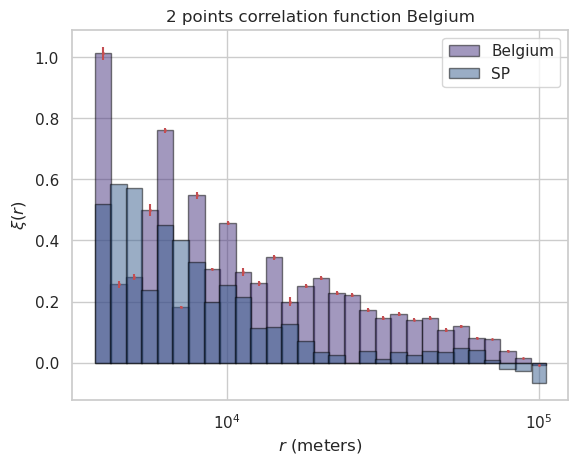

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285629
min DD 15
maxRR 288614
minRR 23
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285629
min DD 15
maxRR 288119
minRR 23
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285629
min DD 15
maxRR 287044
minRR 15
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


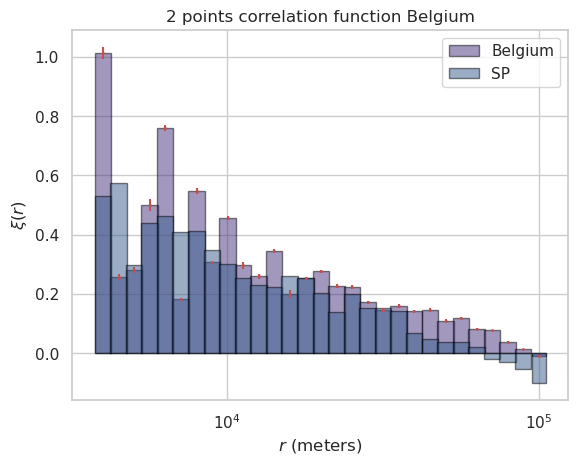

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 277934
min DD 31
maxRR 288210
minRR 42
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 277934
min DD 31
maxRR 289208
minRR 42
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 277934
min DD 31
maxRR 289089
minRR 41
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


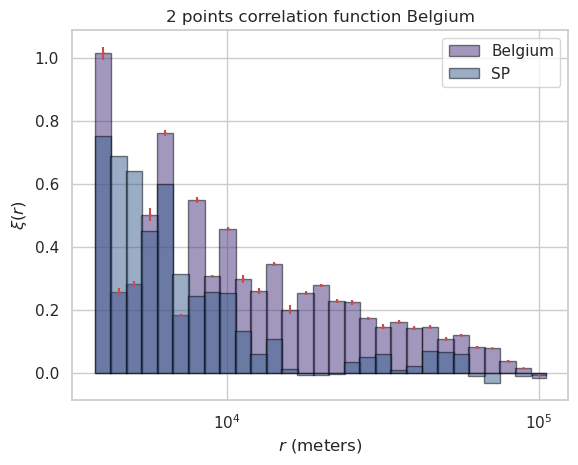

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283718
min DD 22
maxRR 287764
minRR 17
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283718
min DD 22
maxRR 287692
minRR 10
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283718
min DD 22
maxRR 286754
minRR 40
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


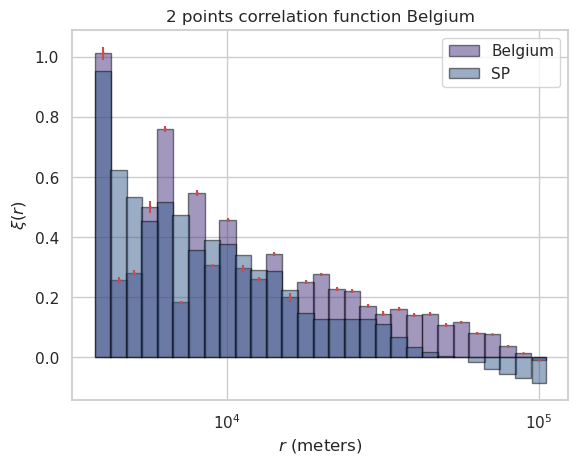

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 270122
min DD 110
maxRR 286777
minRR 10
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 270122
min DD 110
maxRR 285680
minRR 22
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 270122
min DD 110
maxRR 286079
minRR 21
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


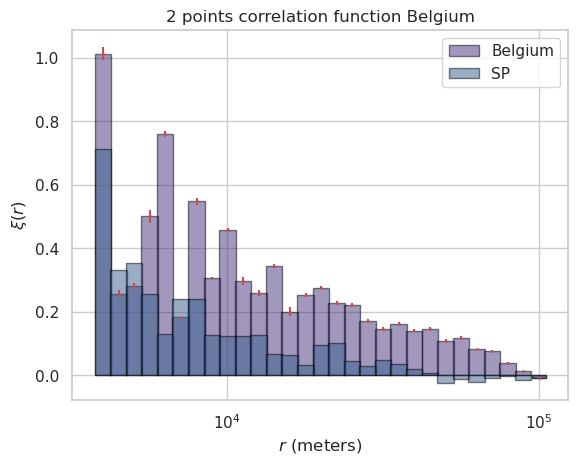

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284092
min DD 178
maxRR 289190
minRR 20
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284092
min DD 178
maxRR 288374
minRR 7
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284092
min DD 178
maxRR 288354
minRR 41
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


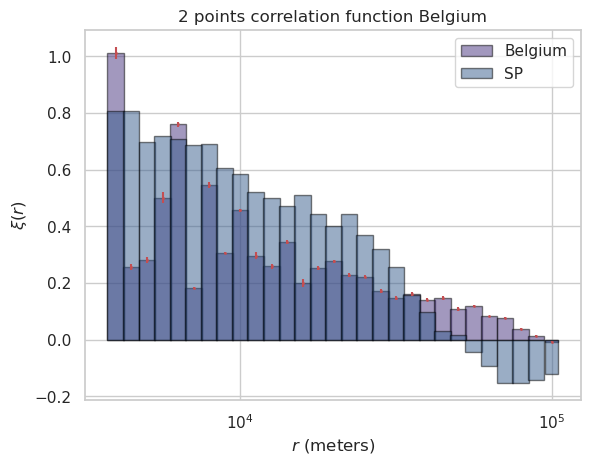

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282285
min DD 219
maxRR 289057
minRR 12
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282285
min DD 219
maxRR 287888
minRR 8
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282285
min DD 219
maxRR 287352
minRR 18
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


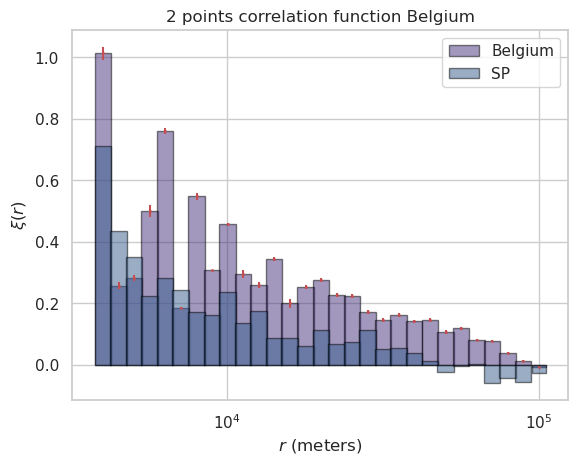

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 286502
min DD 100
maxRR 288576
minRR 11
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 286502
min DD 100
maxRR 288278
minRR 17
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 286502
min DD 100
maxRR 287745
minRR 52
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


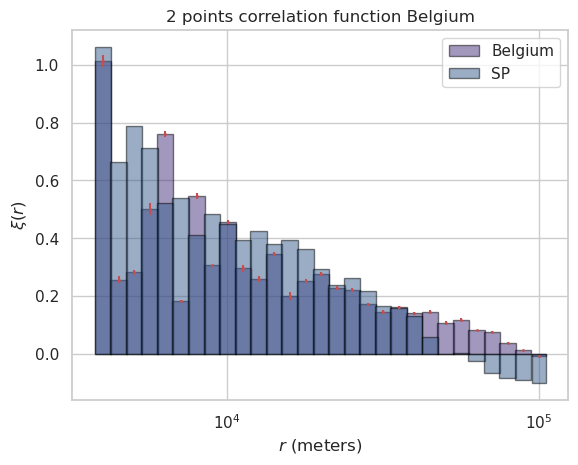

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282527
min DD 127
maxRR 288542
minRR 24
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282527
min DD 127
maxRR 287446
minRR 11
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282527
min DD 127
maxRR 287565
minRR 19
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


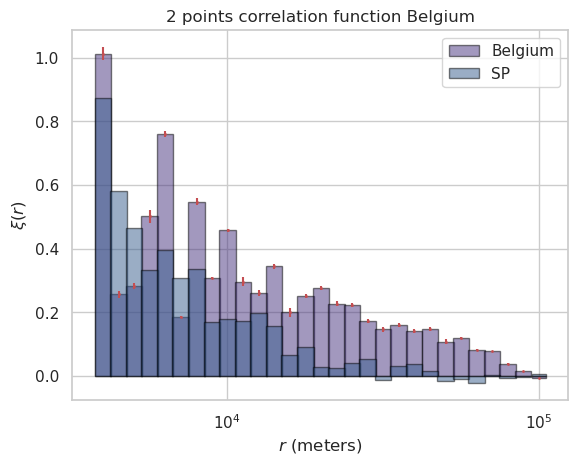

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 276580
min DD 47
maxRR 286605
minRR 35
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 276580
min DD 47
maxRR 288426
minRR 22
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 276580
min DD 47
maxRR 288576
minRR 6
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


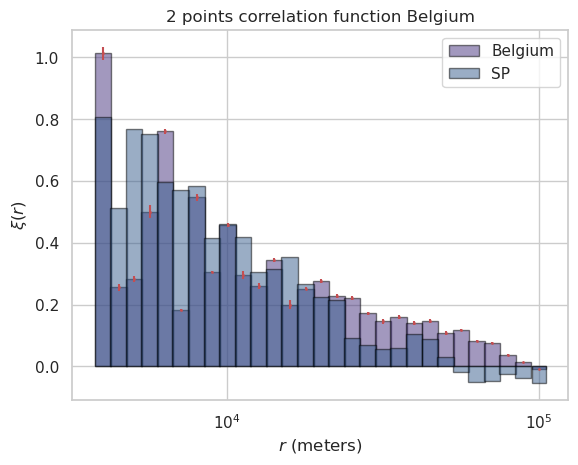

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 277654
min DD 84
maxRR 287396
minRR 2
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 277654
min DD 84
maxRR 287683
minRR 27
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 277654
min DD 84
maxRR 287040
minRR 20
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


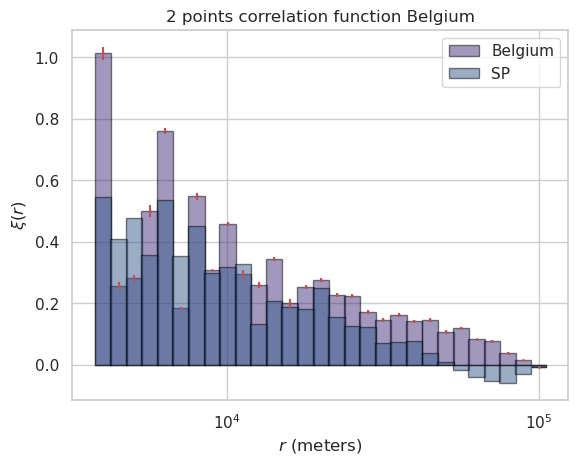

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279243
min DD 9
maxRR 288161
minRR 27
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279243
min DD 9
maxRR 286209
minRR 36
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279243
min DD 9
maxRR 288177
minRR 12
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


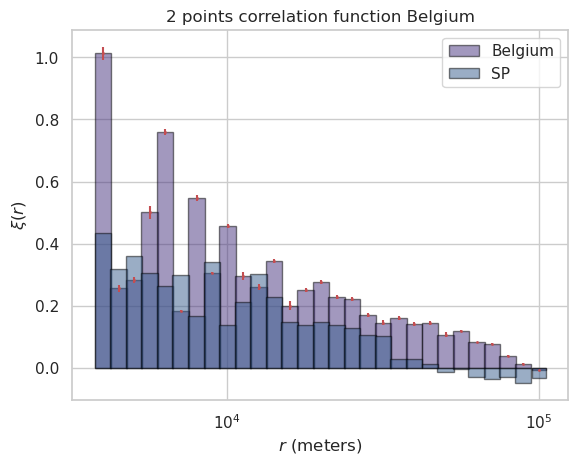

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285087
min DD 79
maxRR 287830
minRR 27
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285087
min DD 79
maxRR 288002
minRR 29
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285087
min DD 79
maxRR 287925
minRR 13
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


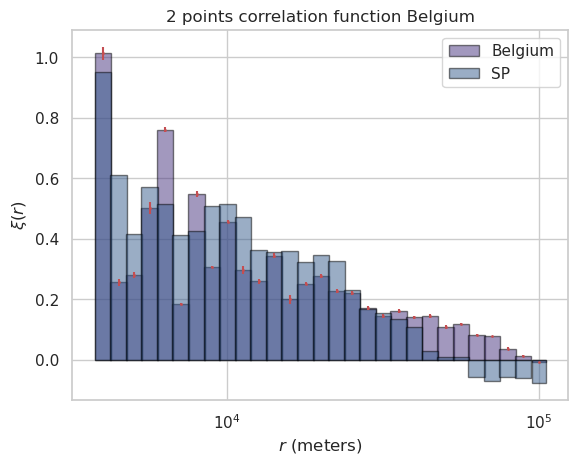

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279878
min DD 45
maxRR 288967
minRR 11
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279878
min DD 45
maxRR 288334
minRR 5
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279878
min DD 45
maxRR 287478
minRR 23
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


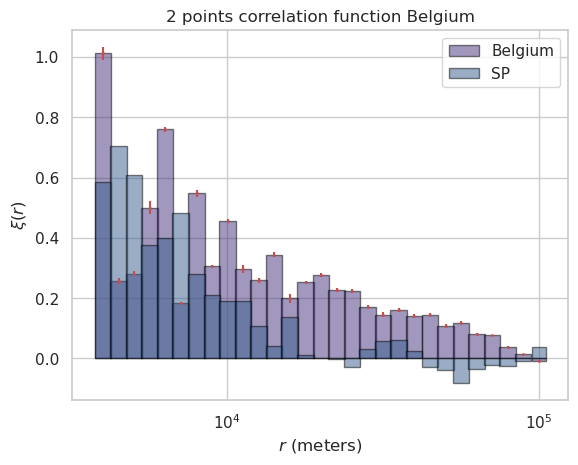

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 276190
min DD 106
maxRR 287636
minRR 5
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 276190
min DD 106
maxRR 288246
minRR 32
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 276190
min DD 106
maxRR 288704
minRR 42
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


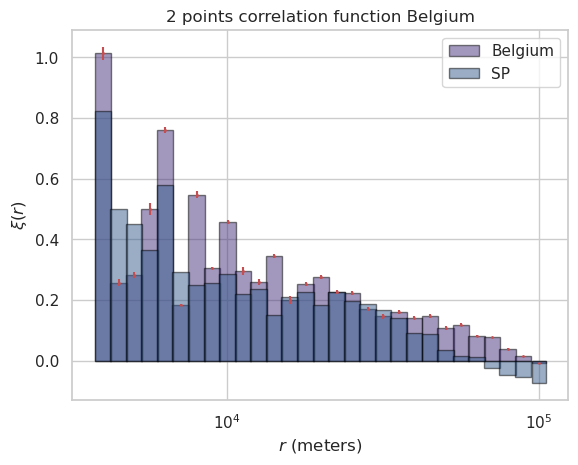

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 278475
min DD 67
maxRR 288488
minRR 41
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 278475
min DD 67
maxRR 287917
minRR 23
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 278475
min DD 67
maxRR 285375
minRR 27
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


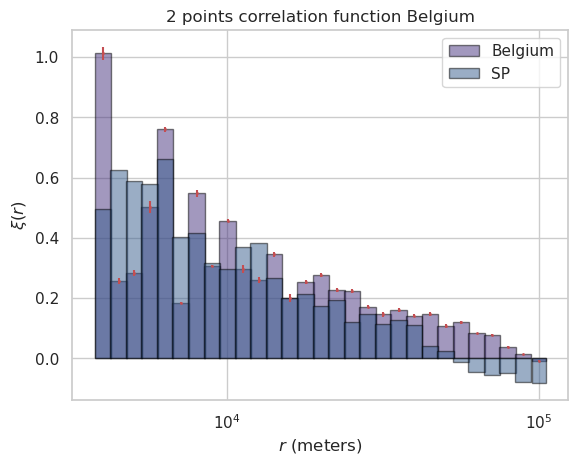

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279008
min DD 67
maxRR 287027
minRR 33
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279008
min DD 67
maxRR 285859
minRR 31
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279008
min DD 67
maxRR 286869
minRR 19
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


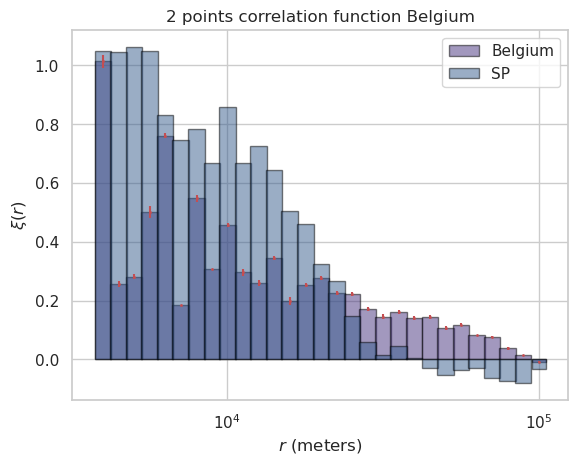

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285364
min DD 133
maxRR 287533
minRR 42
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285364
min DD 133
maxRR 286140
minRR 31
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285364
min DD 133
maxRR 288354
minRR 51
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


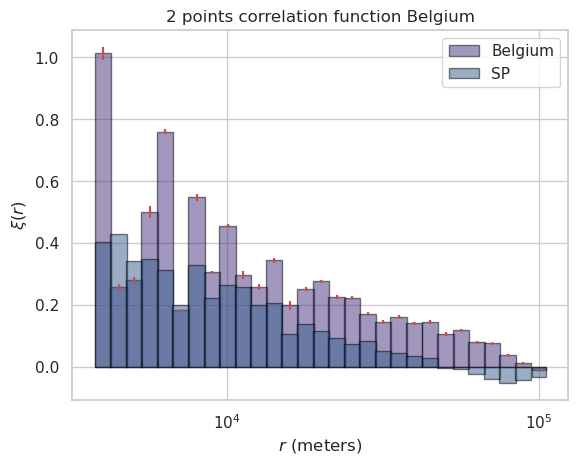

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279759
min DD 232
maxRR 288314
minRR 11
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279759
min DD 232
maxRR 287041
minRR 23
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279759
min DD 232
maxRR 286428
minRR 36
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


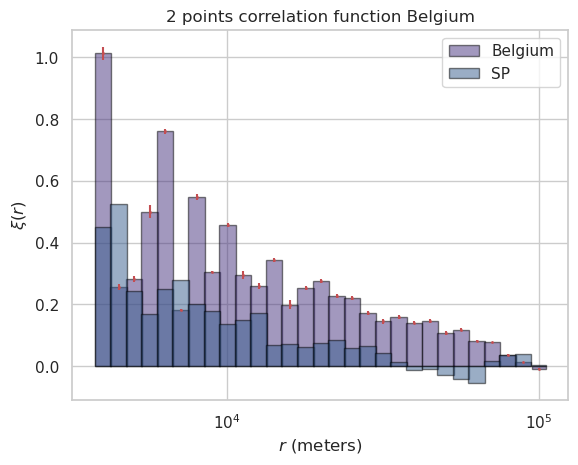

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284509
min DD 80
maxRR 286132
minRR 47
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284509
min DD 80
maxRR 286523
minRR 7
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284509
min DD 80
maxRR 288100
minRR 36
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


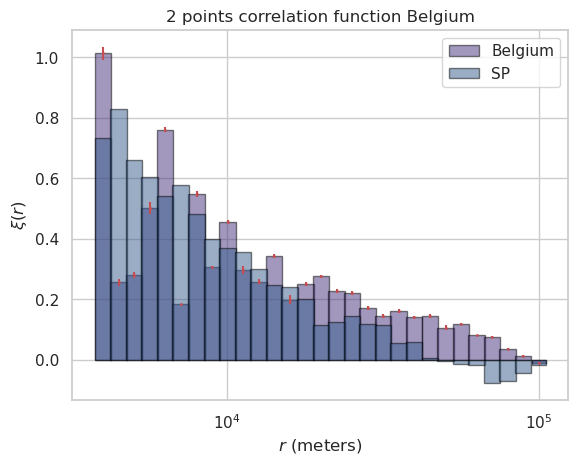

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282992
min DD 113
maxRR 287775
minRR 6
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282992
min DD 113
maxRR 287359
minRR 22
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282992
min DD 113
maxRR 286075
minRR 34
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


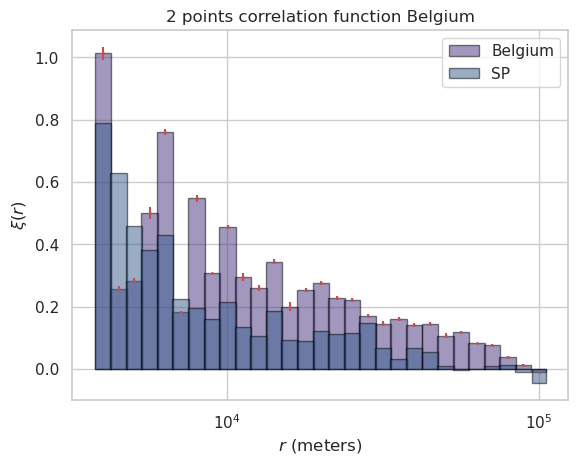

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 276517
min DD 63
maxRR 287977
minRR 28
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 276517
min DD 63
maxRR 288256
minRR 3
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 276517
min DD 63
maxRR 285560
minRR 22
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


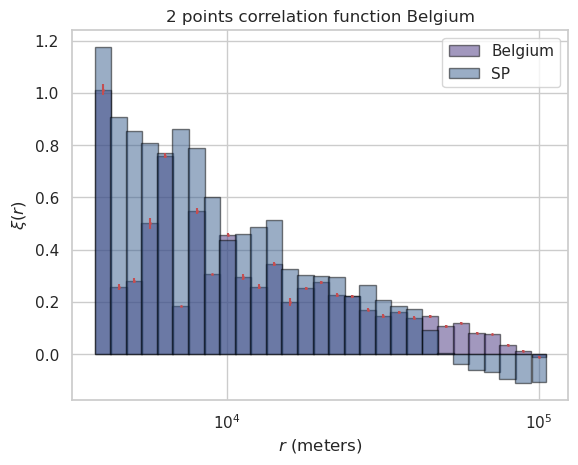

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 277930
min DD 115
maxRR 289882
minRR 27
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 277930
min DD 115
maxRR 288831
minRR 51
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 277930
min DD 115
maxRR 285636
minRR 29
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


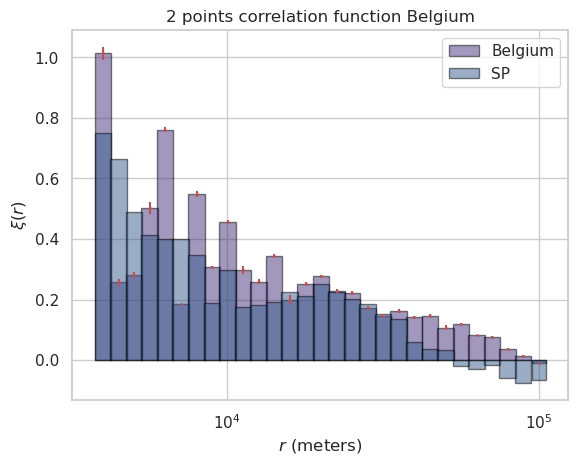

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 274818
min DD 102
maxRR 287163
minRR 25
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 274818
min DD 102
maxRR 287136
minRR 39
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 274818
min DD 102
maxRR 285863
minRR 5
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


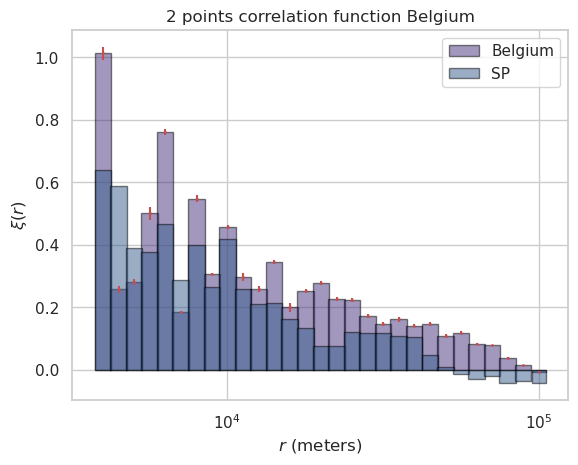

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284524
min DD 137
maxRR 286179
minRR 20
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284524
min DD 137
maxRR 289193
minRR 7
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284524
min DD 137
maxRR 289637
minRR 20
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


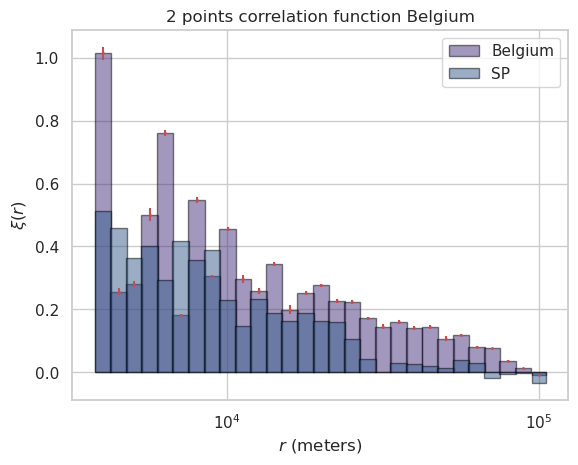

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 278758
min DD 68
maxRR 285858
minRR 18
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 278758
min DD 68
maxRR 288346
minRR 50
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 278758
min DD 68
maxRR 286738
minRR 13
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


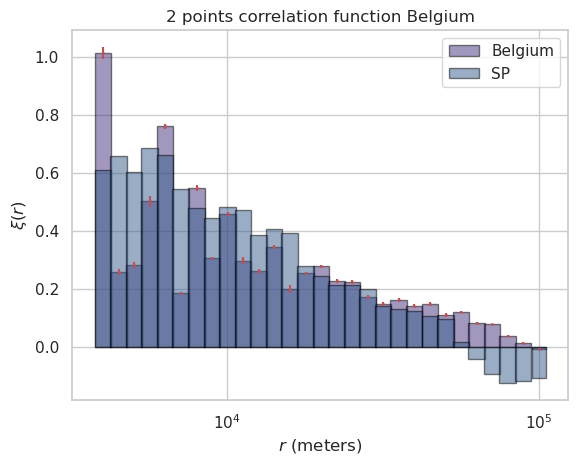

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 277936
min DD 99
maxRR 287782
minRR 29
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 277936
min DD 99
maxRR 288115
minRR 14
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 277936
min DD 99
maxRR 286721
minRR 17
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


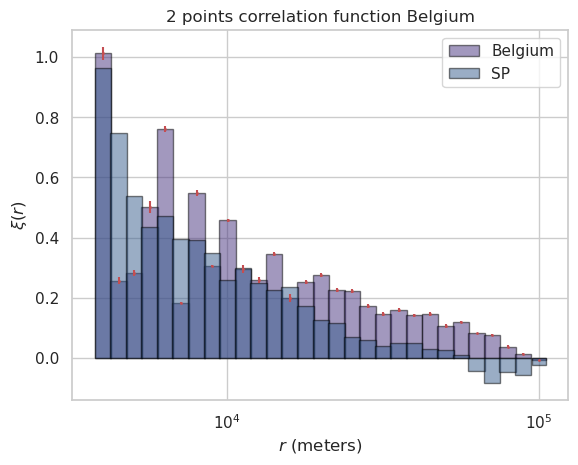

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284163
min DD 136
maxRR 289467
minRR 25
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284163
min DD 136
maxRR 289249
minRR 37
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284163
min DD 136
maxRR 286841
minRR 20
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


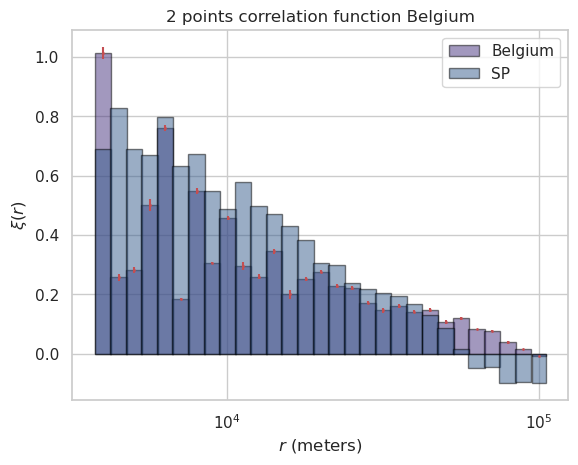

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282082
min DD 25
maxRR 286791
minRR 12
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282082
min DD 25
maxRR 288125
minRR 20
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282082
min DD 25
maxRR 286104
minRR 21
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


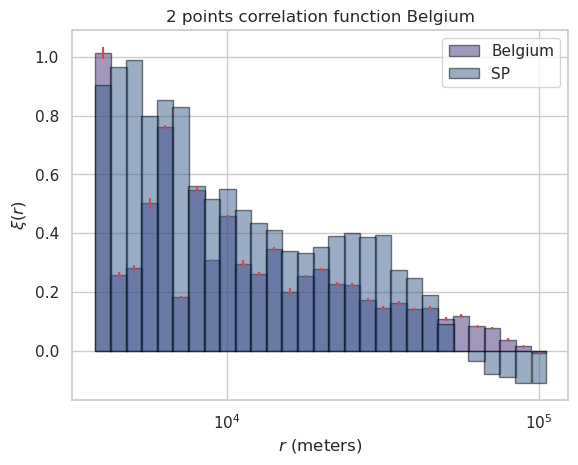

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 275086
min DD 136
maxRR 287849
minRR 11
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 275086
min DD 136
maxRR 287270
minRR 19
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 275086
min DD 136
maxRR 287634
minRR 18
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


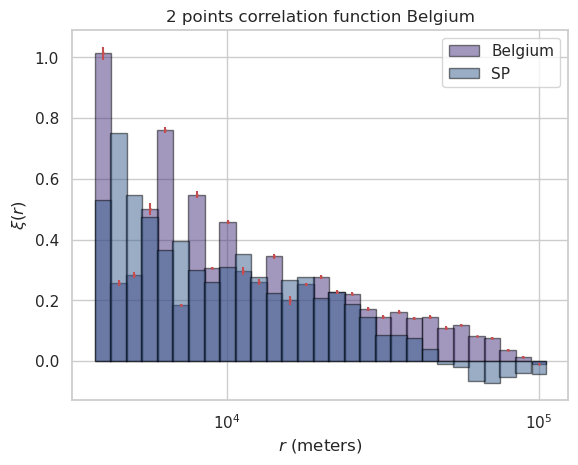

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282856
min DD 93
maxRR 286636
minRR 46
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282856
min DD 93
maxRR 288495
minRR 15
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282856
min DD 93
maxRR 288634
minRR 38
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


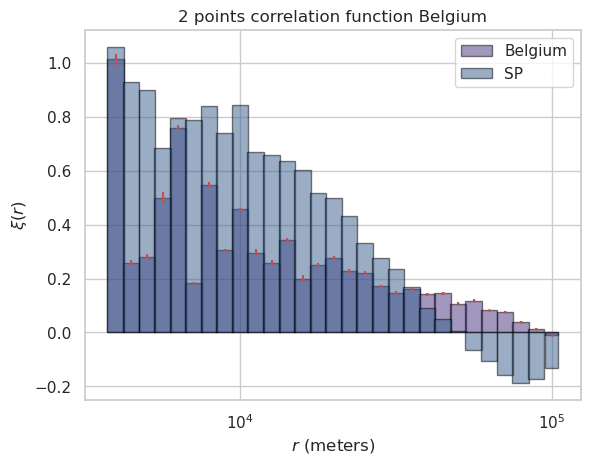

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285340
min DD 23
maxRR 287769
minRR 30
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285340
min DD 23
maxRR 288522
minRR 22
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285340
min DD 23
maxRR 288142
minRR 22
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


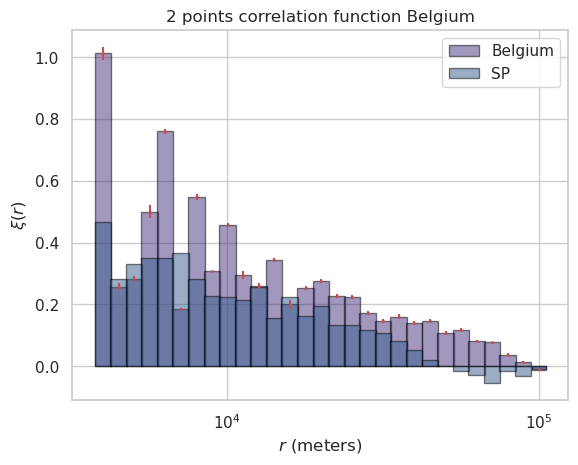

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283771
min DD 85
maxRR 286932
minRR 12
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283771
min DD 85
maxRR 286586
minRR 13
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283771
min DD 85
maxRR 286918
minRR 25
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


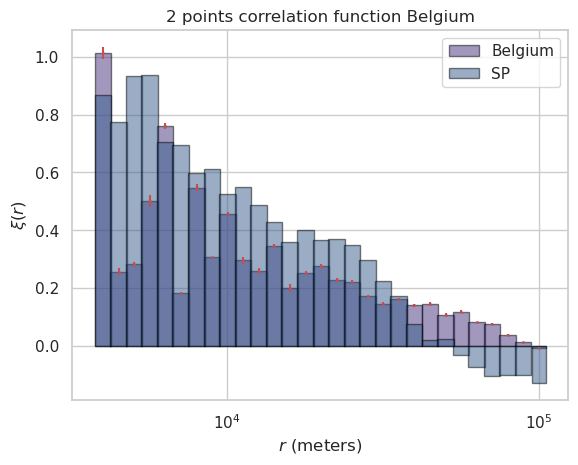

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283355
min DD 58
maxRR 287402
minRR 27
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283355
min DD 58
maxRR 287699
minRR 11
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283355
min DD 58
maxRR 287637
minRR 27
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


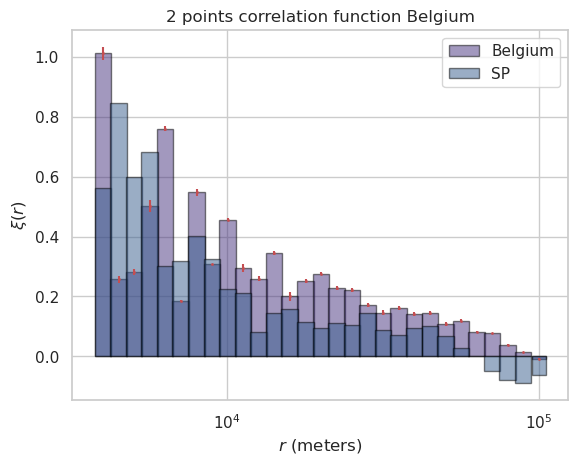

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285465
min DD 240
maxRR 287260
minRR 23
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285465
min DD 240
maxRR 286888
minRR 40
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285465
min DD 240
maxRR 286449
minRR 43
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


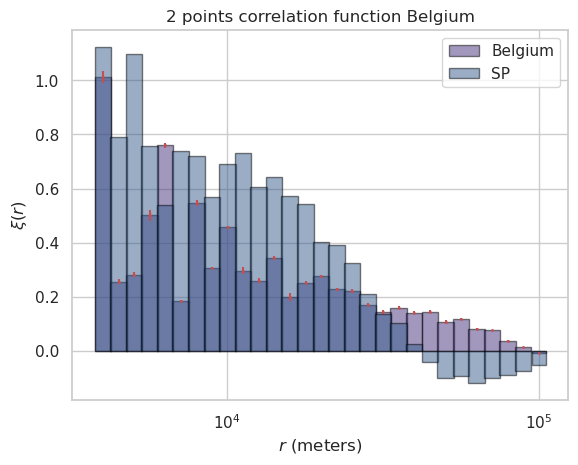

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282822
min DD 224
maxRR 288830
minRR 29
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282822
min DD 224
maxRR 288907
minRR 26
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282822
min DD 224
maxRR 286124
minRR 10
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


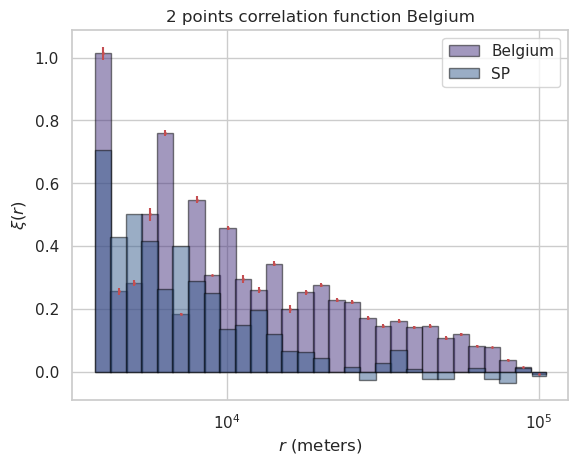

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285473
min DD 86
maxRR 286076
minRR 28
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285473
min DD 86
maxRR 287144
minRR 28
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 285473
min DD 86
maxRR 289569
minRR 19
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


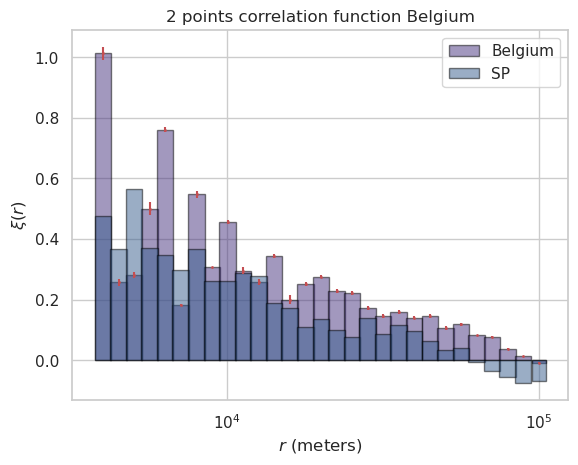

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279533
min DD 85
maxRR 287063
minRR 33
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279533
min DD 85
maxRR 288114
minRR 17
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279533
min DD 85
maxRR 289763
minRR 51
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


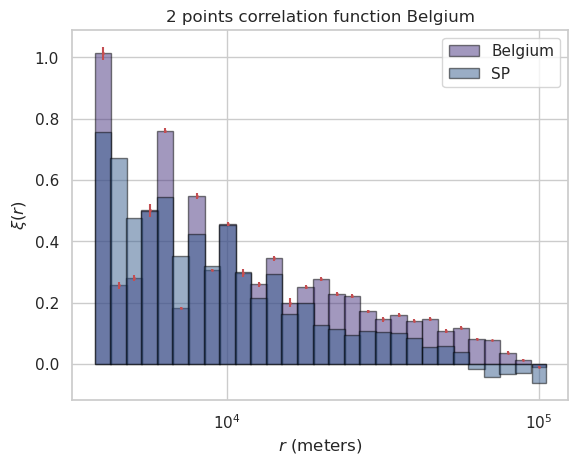

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 277186
min DD 178
maxRR 287510
minRR 16
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 277186
min DD 178
maxRR 287744
minRR 4
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 277186
min DD 178
maxRR 288486
minRR 21
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


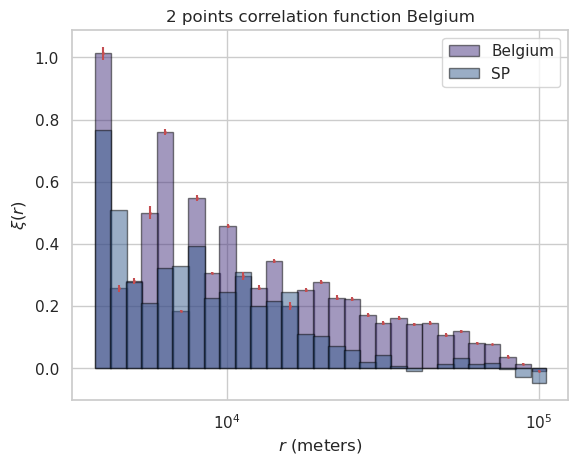

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 275816
min DD 107
maxRR 287507
minRR 11
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 275816
min DD 107
maxRR 287375
minRR 15
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 275816
min DD 107
maxRR 285701
minRR 23
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


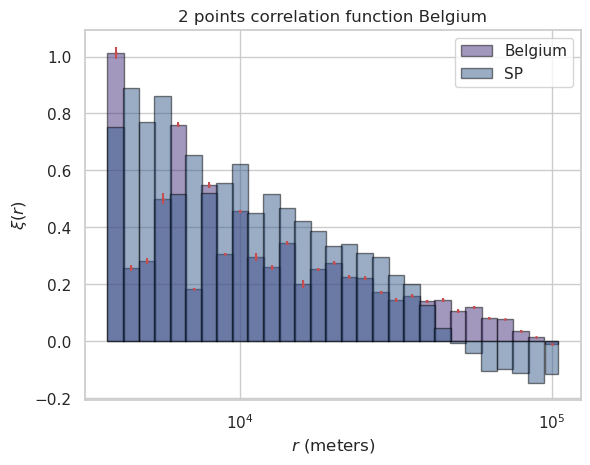

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279758
min DD 216
maxRR 288507
minRR 19
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279758
min DD 216
maxRR 286031
minRR 25
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279758
min DD 216
maxRR 287845
minRR 44
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


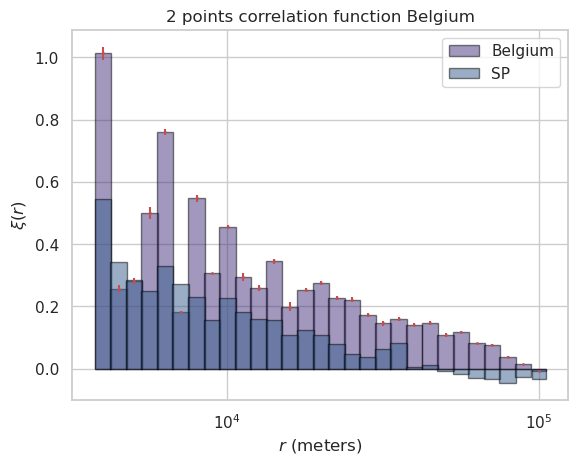

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282815
min DD 151
maxRR 289427
minRR 14
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282815
min DD 151
maxRR 287054
minRR 21
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 282815
min DD 151
maxRR 288518
minRR 16
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


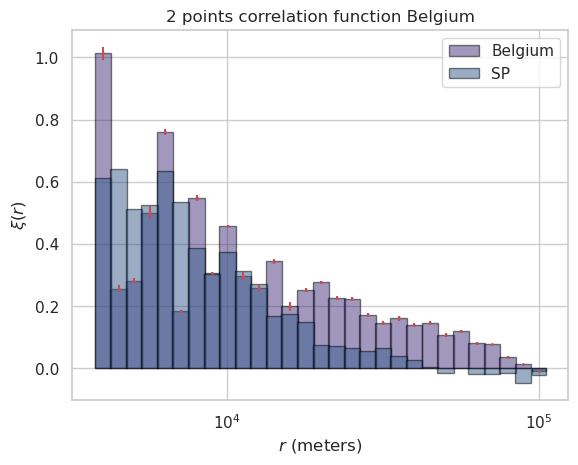

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279684
min DD 75
maxRR 286557
minRR 16
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279684
min DD 75
maxRR 286574
minRR 12
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 279684
min DD 75
maxRR 288747
minRR 39
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


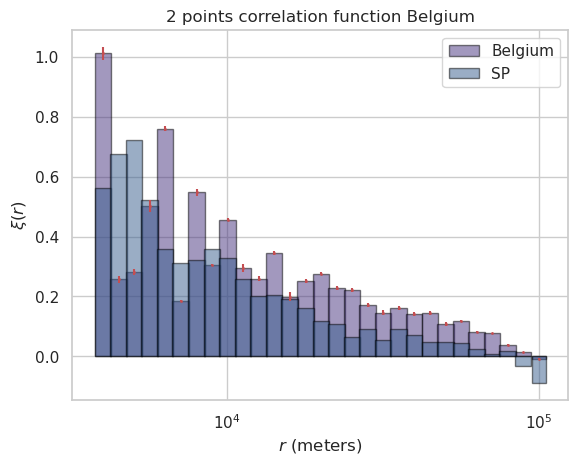

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284727
min DD 95
maxRR 285623
minRR 41
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284727
min DD 95
maxRR 285354
minRR 18
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284727
min DD 95
maxRR 287623
minRR 26
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


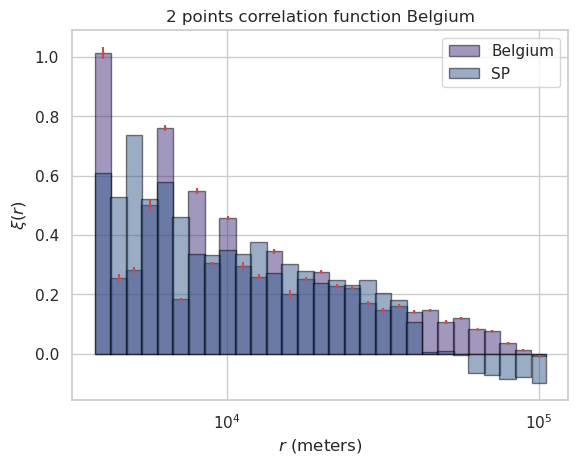

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 278616
min DD 108
maxRR 287408
minRR 28
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 278616
min DD 108
maxRR 286791
minRR 15
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 278616
min DD 108
maxRR 289670
minRR 7
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


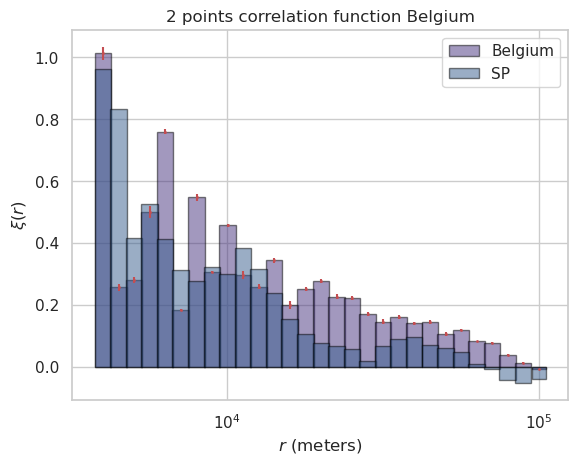

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 281551
min DD 30
maxRR 287868
minRR 15
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 281551
min DD 30
maxRR 286584
minRR 41
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 281551
min DD 30
maxRR 286470
minRR 25
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


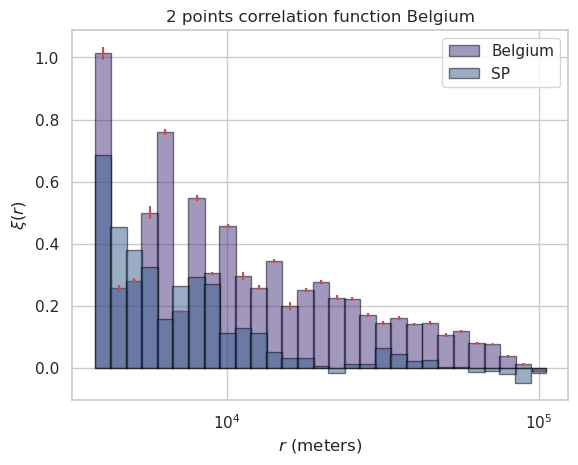

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283836
min DD 127
maxRR 288439
minRR 3
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283836
min DD 127
maxRR 286892
minRR 27
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283836
min DD 127
maxRR 288613
minRR 6
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


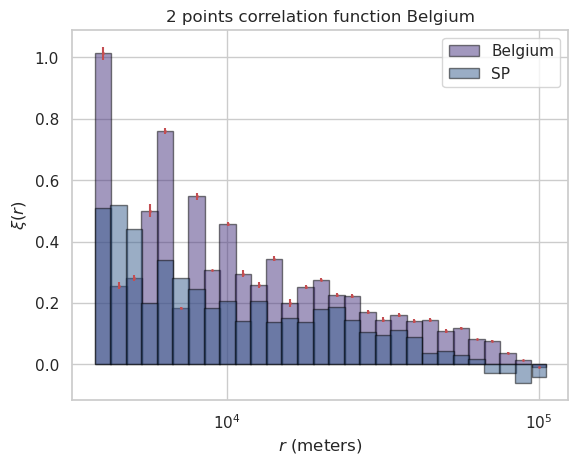

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283416
min DD 62
maxRR 287141
minRR 9
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283416
min DD 62
maxRR 286558
minRR 4
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283416
min DD 62
maxRR 287794
minRR 5
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


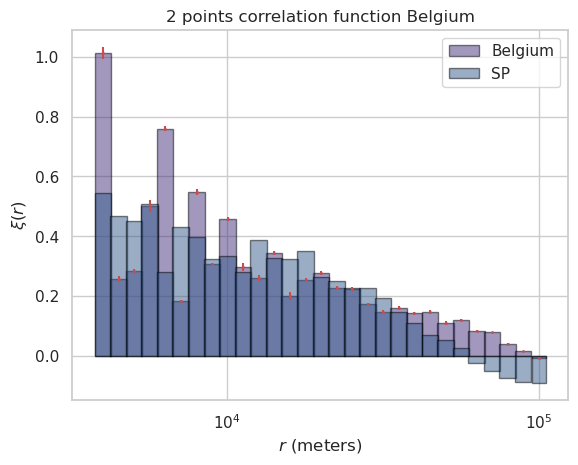

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284342
min DD 85
maxRR 286591
minRR 19
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284342
min DD 85
maxRR 288116
minRR 18
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 284342
min DD 85
maxRR 287745
minRR 20
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


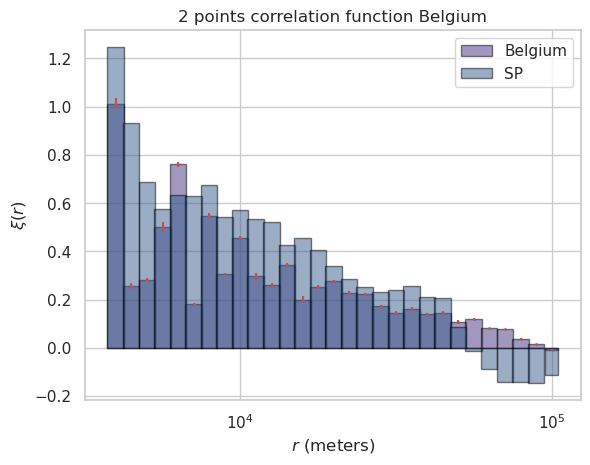

1005
820
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283502
min DD 143
maxRR 288114
minRR 11
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283502
min DD 143
maxRR 286274
minRR 24
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 283502
min DD 143
maxRR 289669
minRR 36
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


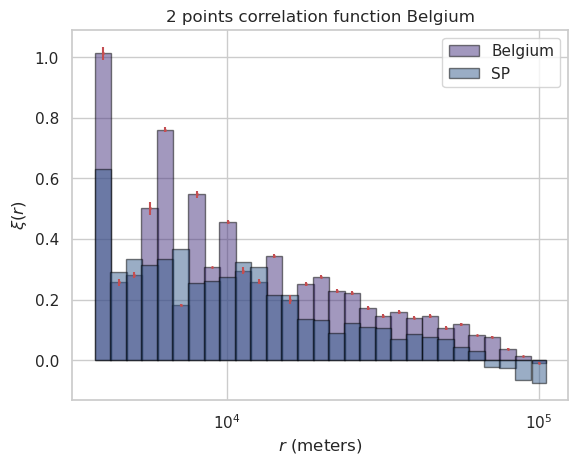

In [29]:
n_iteration = 50 # number of distribution to make
n_short = 25 # number of bins of mall range to consider in KL_short
show_histplot = False
L = save_L[np.argmin(save_dist)] #np.argmin(save_dist)
eta = l_cluster[np.argmin(save_dist)]
l = eta**(1/(2-gamma))
random_point = save_random[np.argmin(save_dist)]
# KLSP,KLrandom
KLSP,KLrandom,KLSP_short,KLrandom_short = compare_log_distribution(n_short,n_iteration,l,eta,L,R,gdf_edge,crs,N,random_point,erase_nodes,k,rmax,scale,nbins,country_distribution,show_histplot)

TtestResult(statistic=-7.270379528827551, pvalue=6.099778357442962e-10, df=64.26848217621368)


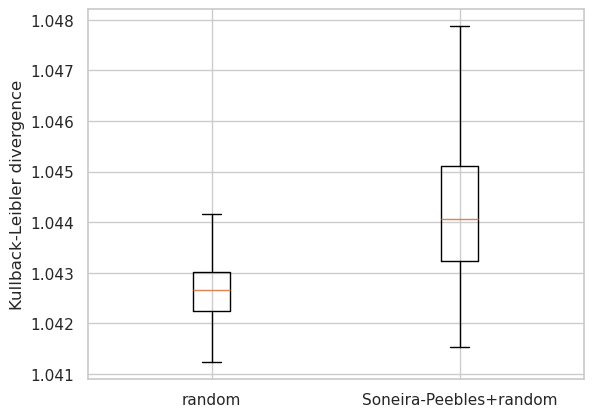

In [30]:
plt.boxplot([KLrandom,KLSP],labels=["random","Soneira-Peebles+random"])
plt.ylabel("Kullback-Leibler divergence")
plt.savefig(plot_dir / ("KL_"+name), format="png",transparent=True)
from scipy.stats import ttest_ind
print(ttest_ind(KLrandom,KLSP,equal_var=False))

TtestResult(statistic=19.509235832048613, pvalue=3.893905583681703e-30, df=70.53111213450393)


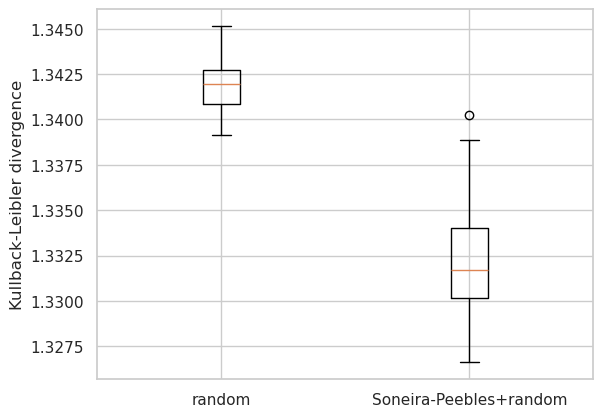

In [31]:
plt.boxplot([KLrandom_short,KLSP_short],labels=["random","Soneira-Peebles+random"])
plt.ylabel("Kullback-Leibler divergence")
plt.savefig(plot_dir / ("KL_short_"+name), format="png",transparent=True)
print(ttest_ind(KLrandom_short,KLSP_short,equal_var=False))

# Save the fitted parameters

In [32]:
save_dir =  Path.cwd().parent /Path(f"out/fitted_parameters_SP/{name}")

In [33]:
L = save_L[np.argmin(save_dist)] #np.argmin(save_dist)
eta = l_cluster[np.argmin(save_dist)]
l = eta**(1/(2-gamma))
random_point = save_random[np.argmin(save_dist)]
dico_results["save_dist"] = save_dist
dico_results["L"] = save_L
dico_results["eta"] = l_cluster
dico_results["save_random"] = save_random
slp.save_results(save_dir,dico_results)

0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 280738
min DD 39
maxRR 288110
minRR 19
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 280738
min DD 39
maxRR 287419
minRR 32
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0
0
1
rmax  100000.0
rmin 3579.2010702384946
max DD 280738
min DD 39
maxRR 289141
minRR 51
rmin,rmax= 3579.2010702384946 100000.0
lenRR 31
lenDD 31
normalization DD  1.0
normalization DR  1.0
normalization RR  1.0


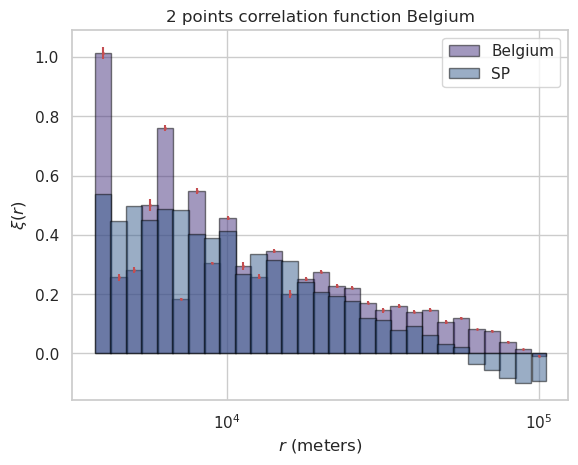

In [42]:
position = check_inside(l,eta,L,R,gdf_edge)
r_edges_random_SP,l_xi_random_SP = make_2pcf_for_model(position,crs,random_point,gdf_edge,rmax)
plot_two_2pcf(r_edges,l_xi,l_xi_random_SP)

In [37]:
print(save_L[np.argmin(save_dist)],l_cluster[np.argmin(save_dist)])

4 4


[1.1798847737494849,
 1.0382155380166718,
 1.0014556722997912,
 1.0799073627906017,
 0.920082085496158]

# Plot an example of the point sprinkle with fitted parameters on the map

256
820


<Axes: >

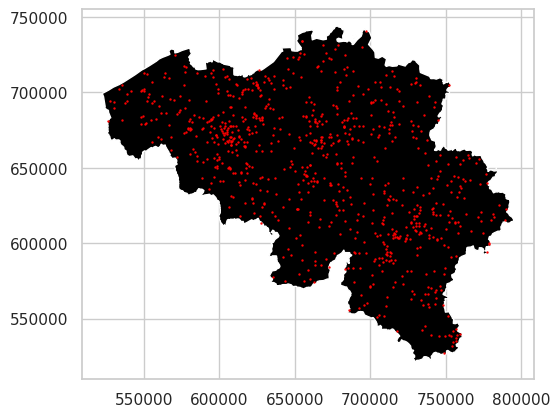

In [39]:
position = check_inside(l,eta,L,R,gdf_edge)
d = {}
d["x"] = position.T[0]
d["y"] = position.T[1]
gdf = gpd.GeoDataFrame(d, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
print(len(gdf))
gdf_random_square = gdf_edge.sample_points(random_point)
gdf_random_points = gpd.GeoDataFrame(gdf_random_square.explode().get_coordinates(),geometry=gdf_random_square.explode(),crs=crs)
gdf = gpd.GeoDataFrame(pd.concat( [gdf,gdf_random_points], ignore_index=True))
l_index = [i for i in range(len(gdf))]
to_drop = np.random.choice(l_index,size=len(l_index)-N,replace=False)
gdf.drop(to_drop, inplace=True)
print(len(gdf))
convex_hull_polygon = gdf.union_all()
polygon = convex_hull_polygon.convex_hull
geoserie = gpd.GeoSeries(polygon)
squares_gdf=gpd.GeoDataFrame({'geometry': geoserie, 'df':[1]},crs=crs)
fig,ax = plt.subplots()
#squares_gdf.plot(ax=ax)
gdf_edge.plot(ax=ax,color="black")
gdf.plot(ax=ax,color="red",markersize=0.5)

In [ ]:
position = check_inside(l,eta,L,R,gdf_edge)
d = {}
d["x"] = position.T[0]
d["y"] = position.T[1]
gdf = gpd.GeoDataFrame(d, geometry=gpd.points_from_xy(position.T[0], position.T[1]),crs=crs)
print(len(gdf))
gdf_random_square = gdf_edge.sample_points(random_point)
gdf_random_points = gpd.GeoDataFrame(gdf_random_square.explode().get_coordinates(),geometry=gdf_random_square.explode(),crs=crs)
gdf = gpd.GeoDataFrame(pd.concat( [gdf,gdf_random_points], ignore_index=True))
l_index = [i for i in range(len(gdf))]
to_drop = np.random.choice(l_index,size=len(l_index)-N,replace=False)
gdf.drop(to_drop, inplace=True)
print(len(gdf))
convex_hull_polygon = gdf.union_all()
polygon = convex_hull_polygon.convex_hull
geoserie = gpd.GeoSeries(polygon)
squares_gdf=gpd.GeoDataFrame({'geometry': geoserie, 'df':[1]},crs=crs)
fig,ax = plt.subplots()
#squares_gdf.plot(ax=ax)
gdf_edge.plot(ax=ax,color="black")
gdf.plot(ax=ax,color="red",markersize=0.5)